# Exploratory Data Analysis (EDA) of Residential Consumption (Public Dataset)

This notebook presents an exploratory analysis of average electricity consumption patterns, alongside the Fourier transforms of weekly consumption data. It generates figures in both the time and frequency domains to compare profiles across representations and across all LCT adoption groups.

Importantly, this notebook relies exclusively on publicly available data.

## Preamble

In [1]:
import yaml
from pathlib import Path
import pandas as pd
import os 
import glob
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import rfft, rfftfreq
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [3]:
# Project location 

## Root:
project_root = Path("..").resolve()  

## Load configuration:
config_path = project_root / "config.yml"
with open(config_path) as f:
    config = yaml.safe_load(f)

data_root = Path(config["data_root"])

data_intermediate = data_root / "Public2024/Intermediate"
data_root_output = data_root / "Output/Public2024"

In [4]:
# Load all household consumption files:
csv_files = glob.glob(os.path.join(data_intermediate, "*.csv"))

# Merge them:
df_list = [pd.read_csv(file) for file in csv_files]
merged_df = pd.concat(df_list, ignore_index=True)

## 1. Direct Space: Electricity Consumption Over Time

In this section, we focus on the time domain and do not yet apply Fourier transforms. We visualize average weekly consumption profiles to examine how electricity usage evolves over the course of a week.

In [5]:
df = merged_df

Retain only the relevant variables and construct additional ones.

In [6]:
# Columns to keep
cols = ['EAN_ID', 'datetime', 'afname_kwh', 'HP','EV', 'PV']
df_small = df[cols].copy()

In [7]:
# Add time variables
df_small['datetime'] = pd.to_datetime(df_small['datetime'])
df_small['week'] = df_small['datetime'].dt.isocalendar().week
df_small['hour_week_quarter'] = ((df_small['datetime'].dt.dayofweek * 24) + df_small['datetime'].dt.hour + df_small['datetime'].dt.minute/60) # Hour of the week

Compute average weekly consumption profiles across households, including disaggregations by LCT ownership. Although not all subgroup series are used in the subsequent analysis, generate them all for completeness.

In [8]:
# LCT ownership groups (a household may also own other LCTs): 

avg_ev = (
    df_small[(df_small['EV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_hp = (
    df_small[(df_small['HP']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_pv = (
    df_small[(df_small['PV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

# Single LCT ownership groups:
avg_ev_only = (
    df_small[(df_small['EV']==1) & (df_small['HP']==0) & (df_small['PV']==0)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_hp_only = (
    df_small[(df_small['EV']==0) & (df_small['HP']==1) & (df_small['PV']==0)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_pv_only = (
    df_small[(df_small['EV']==0) & (df_small['HP']==0) & (df_small['PV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

# Mixing:
avg_all = (
    df_small[(df_small['EV']==1) & (df_small['HP']==1) & (df_small['PV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_ev_hp_only = (
    df_small[(df_small['EV']==1) & (df_small['HP']==1) & (df_small['PV']==0)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_ev_pv_only = (
    df_small[(df_small['EV']==1) & (df_small['HP']==0) & (df_small['PV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_hp_pv_only = (
    df_small[(df_small['EV']==0) & (df_small['HP']==1) & (df_small['PV']==1)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

Define a baseline against which to compare households owning a given LCT. Consider three alternative baseline definitions:
1. Non-owners of a given LCT: all other households. This group may still include households owning other LCTs, and class imbalance can make comparisons difficult to interpret.
2. LCT non-owners: households that do not own any LCT.
3. Reweighted sample: a weighted version of the data, constructed to approximate the characteristics of the average Flemish household. The weights combine external statistics (national and regional) with simple heuristics. Note that full representativeness cannot be guaranteed due to data limitations.
______

References for weighting procedure:  

- Rosenow, J., Gibb, D., Nowak, T., Lowes, R., 2022. Heating up the global heat pump market. Nature Energy 7, 901–904. doi:10.1038/s41560-022-01104-8.
- Statbel, 2023. Belgium has 1.8 million one-person households in 2023. URL: https://statbel.fgov.be/en/news/belgium-has-18-million-one-person-households-2023. published 8 June 2023; data as of 1 January 2023.
- Statbel, 2025. Vehicle stock. URL: https://statbel.fgov.be/en/themes/mobility/traffic/vehicle-stock. published 16 September 2025.
- Vlaamse Regulator van de Elektriciteits- en Gasmarkt, 2024. Marktmonitor 2024. URL: https://www.vlaamsenutsregulator.be/sites/default/files/document/rapp-2024-16-marktmonitor_2024.pdf.

In [9]:
# Baseline 1: Non-owners of the specific LCT

avg_no_ev = (
    df_small[df_small['EV']==0]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_no_hp = (
    df_small[df_small['HP']==0]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

avg_no_pv = (
    df_small[df_small['PV']==0]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

# Baseline 2: LCT non-owners:

avg_none = (
    df_small[(df_small['PV'] == 0) & (df_small['HP'] == 0) & (df_small['EV'] == 0)]
    .groupby('hour_week_quarter')['afname_kwh']
    .mean()
)

# Baseline 3: reweighted:

weights = {
    # Statistics: 
    'EV': 0.03,    # Cf. (Statbel, 2023) and (Statbel, 2025)
    'HP': 0.04,    # Cf. (Rosenow et al., 2022) 
    'PV': 0.40,    # Cf. (Vlaamse Regulator van de Elektriciteits- en Gasmarkt, 2024)
    # Heuristics (average of Fréchet inequalities): 
    'EV+HP+PV': 0.015,   
    'EV+HP': 0.015,
    'EV+PV': 0.015, 
    'HP+PV': 0.020,
    # Constraint: 
    'None': 1 - 0.40 - 0.04 - 0.03 - 0.015 - 0.015 - 0.015 - 0.020
}

avg_reweighted = (
    weights['EV'] * avg_ev_only + weights['HP'] * avg_hp_only + weights['PV'] * avg_pv_only 
    + weights['EV+HP+PV'] * avg_all + weights['EV+HP'] * avg_ev_hp_only + weights['EV+PV'] * avg_ev_pv_only + weights['HP+PV'] * avg_hp_pv_only
    + weights['None'] * avg_none
)

Plot the weekly average consumption profile by hour (quarter-hourly observations) for each LCT group. Compare EV, HP, and PV owners to three alternative baselines: non-owners of the same LCT, households without any LCT, and the reweighted baseline. Show each weekly profile in a separate plot for each LCT type (EV, HP, or PV).

In [10]:
# Plot parameters: 

## Ticks when day of week changes: 
ticks = [0, 24, 48, 72, 96, 120, 144]
dic = {0: "Mon", 24: "Tue", 48: "Wed", 72: "Thu", 96: "Fri", 120: "Sat", 144: "Sun"}
labels = [dic[t] for t in ticks]

## Figure size: 
size = 6 

## y axis scale (in kWh): 
y_min = 0 
y_max = 0.35

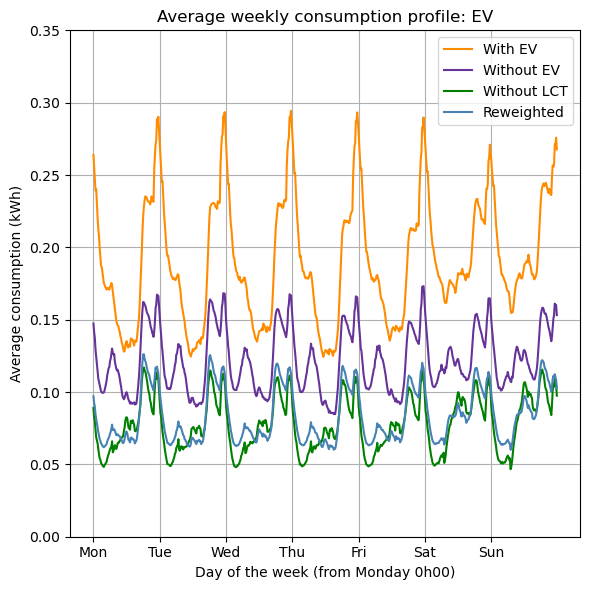

In [11]:
# Plot 1: EV

fig, ax = plt.subplots(figsize=(size, size))

ax.plot(avg_ev.index, avg_ev.values, label='With EV', linewidth=1.5, color = 'darkorange')
ax.plot(avg_no_ev.index, avg_no_ev.values, label='Without EV', linewidth=1.5,color = 'rebeccapurple')
ax.plot(avg_none.index, avg_none.values, label='Without LCT', linewidth=1.5, color = 'green')
ax.plot(avg_reweighted.index, avg_reweighted.values, label='Reweighted', linewidth=1.5, color='steelblue')

ax.set_xlabel("Day of the week (from Monday 0h00)")
ax.set_ylabel("Average consumption (kWh)")
ax.set_title("Average weekly consumption profile: EV")

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.legend()
ax.grid(True)

plt.ylim((y_min, y_max))

plt.tight_layout()
plt.savefig(data_root_output/'weekly_avg_profile_EV.pdf')
plt.show()

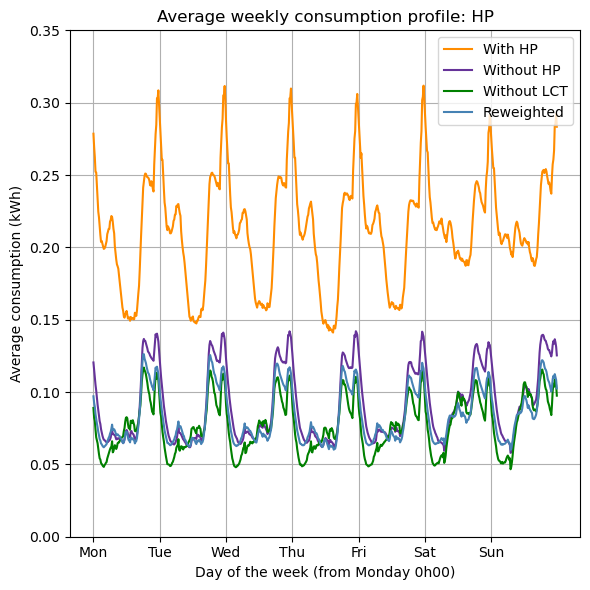

In [12]:
#Plot 2: HP

fig, ax = plt.subplots(figsize=(size,size))

ax.plot(avg_hp.index, avg_hp.values, label='With HP', linewidth=1.5, color = 'darkorange')
ax.plot(avg_no_hp.index, avg_no_hp.values, label='Without HP', linewidth=1.5,color = 'rebeccapurple')
ax.plot(avg_none.index, avg_none.values, label='Without LCT', linewidth=1.5, color = 'green')
ax.plot(avg_reweighted.index, avg_reweighted.values, label='Reweighted', linewidth=1.5, color='steelblue')

ax.set_xlabel("Day of the week (from Monday 0h00)")
ax.set_ylabel("Average consumption (kWh)")
ax.set_title("Average weekly consumption profile: HP")

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.legend()
ax.grid(True)

plt.ylim((y_min, y_max))

plt.tight_layout()
plt.savefig(data_root_output/'weekly_avg_profile_HP.pdf')
plt.show()

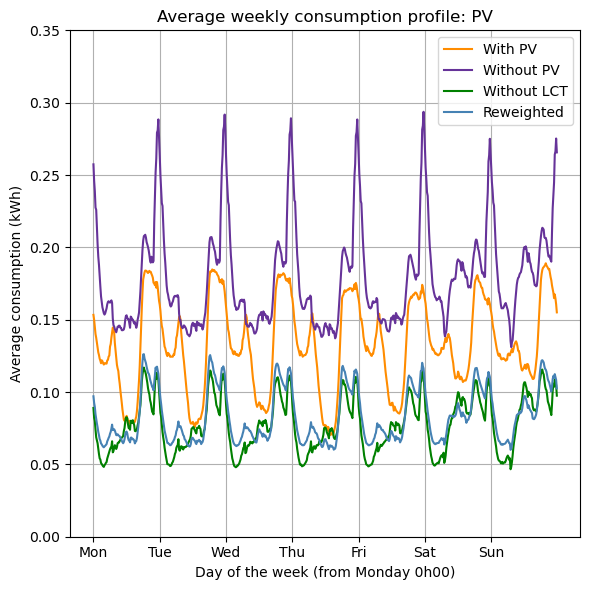

In [13]:
#Plot 3: PV

fig, ax = plt.subplots(figsize=(size, size))

ax.plot(avg_pv.index, avg_pv.values, label='With PV', linewidth=1.5, color = 'darkorange')
ax.plot(avg_no_pv.index, avg_no_pv.values, label='Without PV', linewidth=1.5,color = 'rebeccapurple')
ax.plot(avg_none.index, avg_none.values, label='Without LCT', linewidth=1.5, color = 'green')
ax.plot(avg_reweighted.index, avg_reweighted.values, label='Reweighted', linewidth=1.5, color='steelblue')

ax.set_xlabel("Day of the week (from Monday 0h00)")
ax.set_ylabel("Average consumption (kWh)")
ax.set_title("Average weekly consumption profile: PV")

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.legend()
ax.grid(True)

plt.ylim((y_min, y_max))

plt.tight_layout()
plt.savefig(data_root_output/'weekly_avg_profile_PV.pdf')
plt.show()

## 2. Fourier Space: Electricity Consumption Across Frequencies

Household electricity consumption can be viewed as the combination of multiple periodic patterns arising from different appliances and routines. Fourier analysis converts time-domain consumption data into the frequency domain, revealing the frequency, amplitude, and phase of these underlying patterns. This allows the identification of recurring behaviors across multiple time scales, from minutes to weeks.

Transform the pandas Series constructed above into Numpy arrays, as required for the Fourier implementation. Compute the Fourier transform using the Fast Fourier Transform (FFT) algorithm. To avoid cluttering plots, the baseline is selected as the 'reweighted baseline', while noting that the code can be easily adapted to other baseline definitions.

In [14]:
# From Series to Arrays:

x_ev = avg_ev.values
x_hp = avg_hp.values
x_pv = avg_pv.values
x_baseline = avg_reweighted.values

# Computing Fourier transforms:

## Sample spacing (in seconds --> Fourier frequency is in 1/s = Hz):
dt = 15 * 60  # 15 min in seconds

## Fourier: 
freqs = rfftfreq(len(x_baseline), dt)  # len(x_baseline) = len(x_ev) = len(x_hp) = ... in this context

fft_ev = np.abs(rfft(x_ev))
fft_hp = np.abs(rfft(x_hp))
fft_pv = np.abs(rfft(x_pv))
fft_baseline = np.abs(rfft(x_baseline))

Plot parameter setting.

In [15]:
# Plot parameters: 

## Frequency limits (in s) for different bands of interest:  
freq_max = 1/(2*dt)  # Maximal frequency detectable by FFT is half the sampling frequency, or equivalently, double the sampling period (= 2 * 15 = 30 mins).
freq_7day = 1/(7*24*60*60)
freq_1day = 1/(24*60*60)
freq_6h = 1/(6*60*60)

## Figure size: 
size = 6 

## y axis scale (amplitude, proportional to energy): 
y_min = 0 
y_max = 20

Plot the weekly average consumption amplitude by frequency for each LCT group. For interpretation, shaded areas are overlayed to indentify low frequency regimes (> 1 day), medium frequency regimes (between 6 hours and 1 day) and high frequency regimes (< 6 hours, down to 30 mins). 

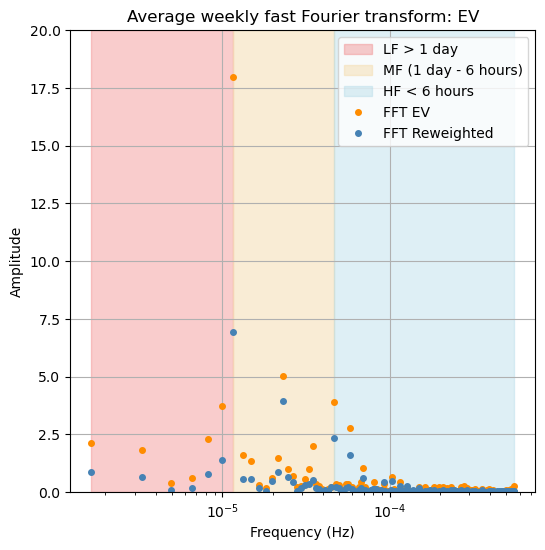

In [16]:
# Plot 1: FFT EV

fig, ax = plt.subplots(figsize=(size,size))

ax.axvspan(freq_7day, freq_1day, alpha=0.4, color='lightcoral', label='LF > 1 day')
ax.axvspan(freq_1day, freq_6h, alpha=0.55, color='wheat', label='MF (1 day - 6 hours)')
ax.axvspan(freq_6h, freq_max, alpha=0.4, color='lightblue', label='HF < 6 hours')

plt.plot(freqs, fft_ev, 'o', label='FFT EV', markersize=4, color = 'darkorange')
plt.plot(freqs, fft_baseline, 'o', label='FFT Reweighted', markersize=4, color = 'steelblue')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Average weekly fast Fourier transform: EV")
plt.ylim((y_min, y_max))
plt.legend()
plt.grid(True)
plt.savefig(data_root_output/'FFT_weekly_avg_profile_EV.pdf')
plt.show()

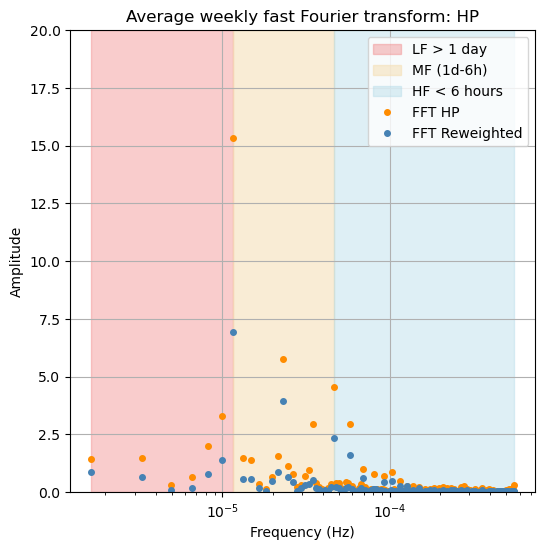

In [17]:
# Plot 2: FFT HP

fig, ax = plt.subplots(figsize=(size,size))

ax.axvspan(freq_7day, freq_1day, alpha=0.4, color='lightcoral', label='LF > 1 day')
ax.axvspan(freq_1day, freq_6h, alpha=0.55, color='wheat', label='MF (1d-6h)')
ax.axvspan(freq_6h, freq_max, alpha=0.4, color='lightblue', label='HF < 6 hours')

plt.plot(freqs, fft_hp, 'o', label='FFT HP', markersize=4, color = 'darkorange')
plt.plot(freqs, fft_baseline, 'o', label='FFT Reweighted', markersize=4, color = 'steelblue')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Average weekly fast Fourier transform: HP")
plt.ylim((y_min, y_max))
plt.legend()
plt.grid(True)
plt.savefig(data_root_output/'FFT_weekly_avg_profile_HP.pdf')
plt.show()

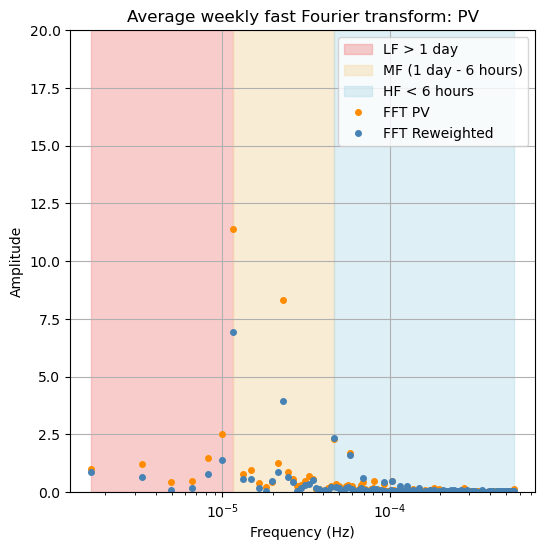

In [18]:
# Plot 3: FFT PV

fig, ax = plt.subplots(figsize=(size,size))

ax.axvspan(freq_7day, freq_1day, alpha=0.4, color='lightcoral', label='LF > 1 day')
ax.axvspan(freq_1day, freq_6h, alpha=0.55, color='wheat', label='MF (1 day - 6 hours)')
ax.axvspan(freq_6h, freq_max, alpha=0.4, color='lightblue', label='HF < 6 hours')

plt.plot(freqs, fft_pv, 'o', label='FFT PV', markersize=4, color = 'darkorange')
plt.plot(freqs, fft_baseline, 'o', label='FFT Reweighted', markersize=4, color = 'steelblue')
plt.xscale('log')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Average weekly fast Fourier transform: PV")
plt.ylim((y_min, y_max))
plt.legend()
plt.grid(True)
plt.savefig(data_root_output/'FFT_weekly_avg_profile_PV.pdf')
plt.show()

Refer to the paper for interpretation of the plots. 